<a href="https://colab.research.google.com/github/malealvarez/malealvarez/blob/main/aden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Leargning - Linear Regression

1) Carga de los datos de Kaggle.
2) Exploración y preparación de los datos (limpieza, selección de variables).
3) Separación de los datos en características (X) y variable objetivo (y).
4) División de los datos en conjuntos de entrenamiento y prueba.
5) Entrenamiento del modelo de regresión lineal.
6) Evaluación del desempeño del modelo.

Carga de database

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

100%|██████████| 48.5k/48.5k [00:00<00:00, 33.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nikhil7280/student-performance-multiple-linear-regression/versions/1


In [ ]:
import os
print(os.listdir(path))

['Student_Performance.csv']


In [ ]:
import pandas as pd
data = pd.read_csv(f"{path}/Student_Performance.csv")
print(data.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


Limpieza de datos

In [ ]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
# Mostrar la tabla con configuración para mejor vista
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.width', 1000)        # Ajustar ancho de impresión
print(data.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  Sample Question Papers Practiced  Performance Index
0              7               99                           1            9                                 1               91.0
1              4               82                           0            4                                 2               65.0
2              8               51                           1            7                                 2               45.0
3              5               52                           1            5                                 2               36.0
4              7               75                           0            8                                 5               66.0


In [ ]:
num_filas = data.shape[0]
print(f"La base de datos tiene {num_filas} filas.")

La base de datos tiene 10000 filas.


In [ ]:
print(data.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Exploración de datos y análisis de correlaciones

Gráfico de pares

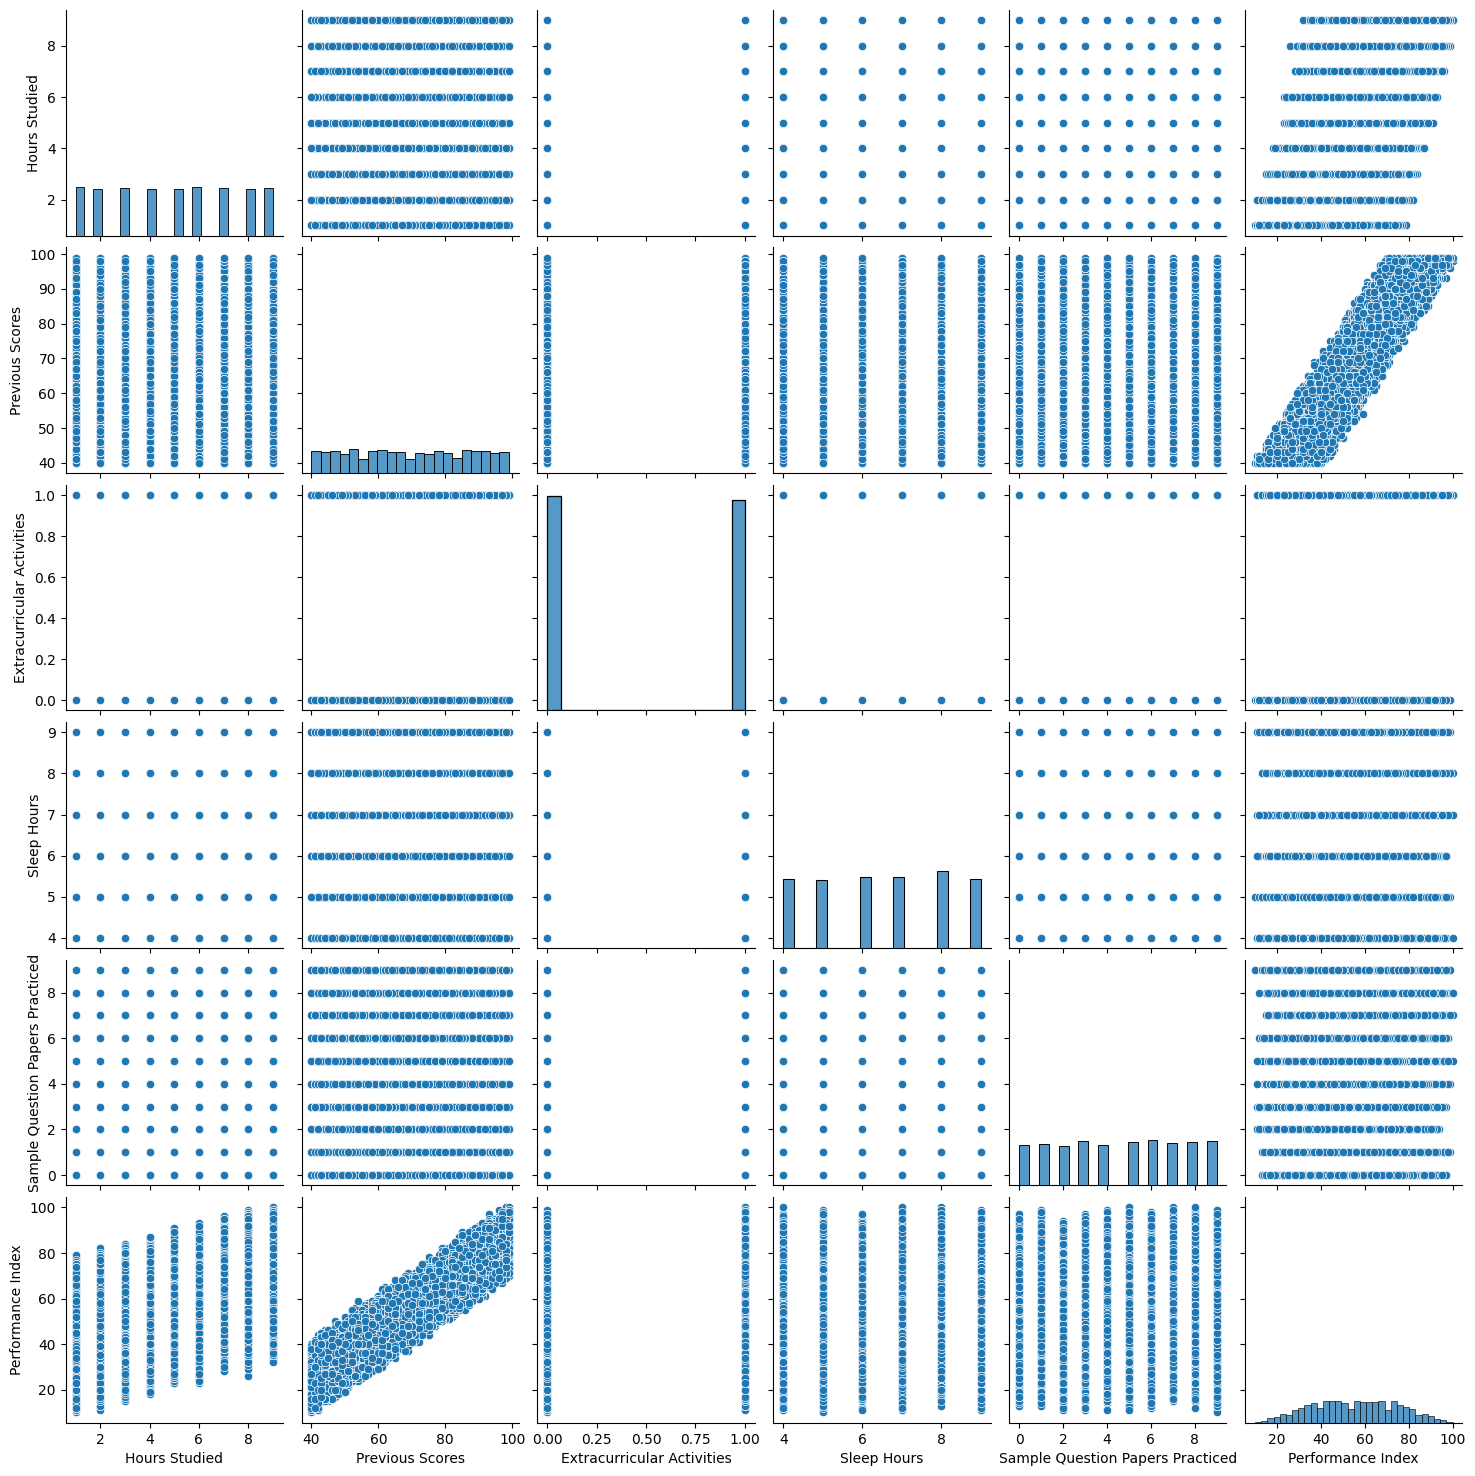

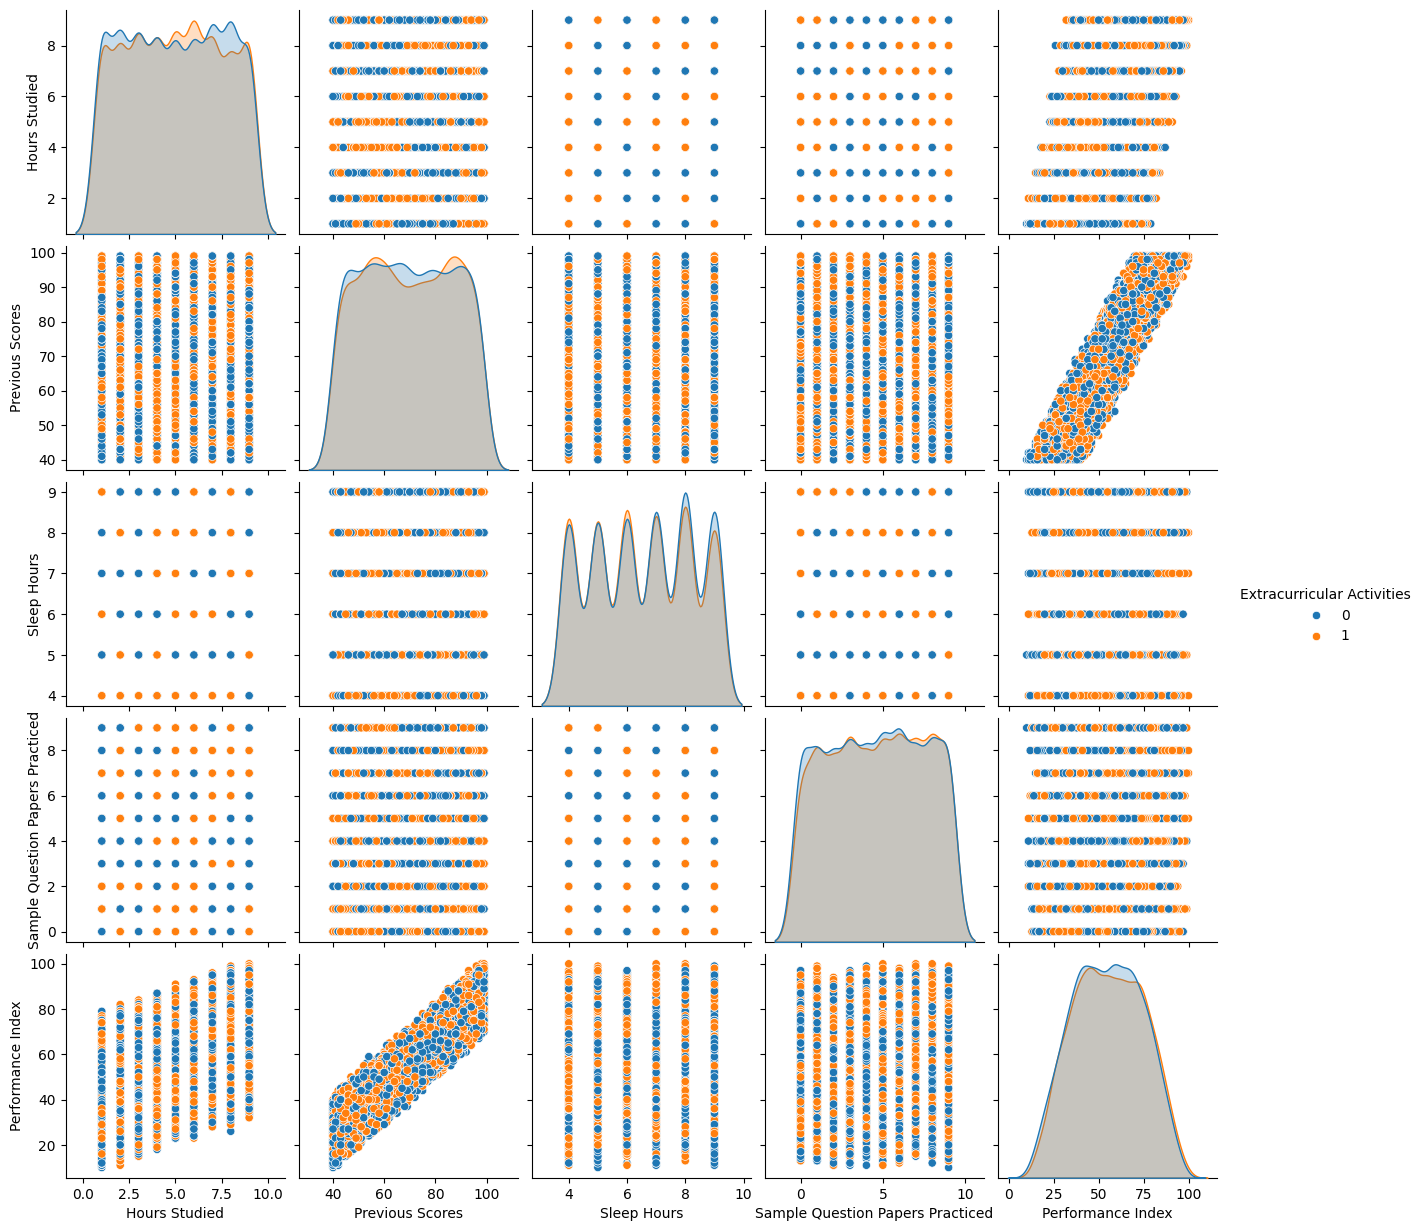

In [ ]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
# Crear gráfico de pares (pairplot)
sns.pairplot(data)
# Mostrar gráfico
plt.show()
sns.pairplot(data, hue='Extracurricular Activities')
plt.show()

Mapa de calor con matriz de correlación

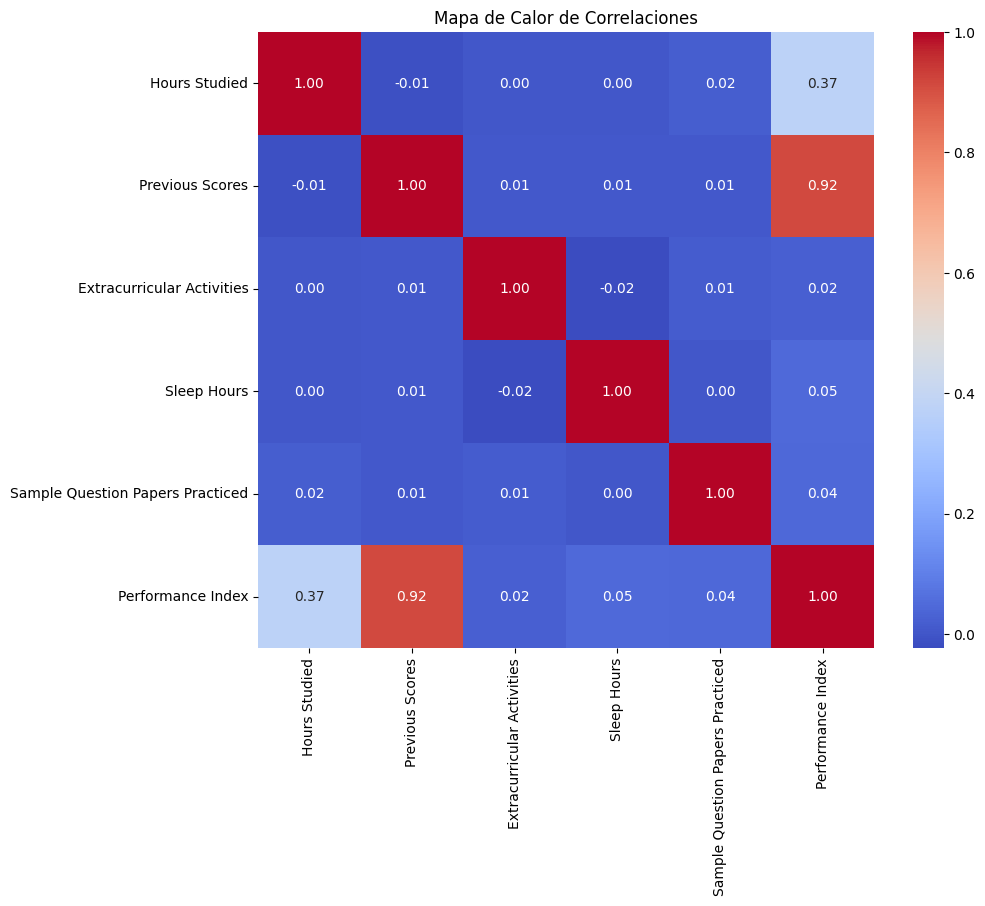

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Calcular matriz de correlación
corr = data.corr()
# Crear mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

Modelo ML

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Separar variables predictoras y variable objetivo
X = data.drop('Performance Index', axis=1) # X son todos los datos sin la variables que se predice
y = data['Performance Index'] # Y son los datos de la variables que se predice

# Dividir en entrenamiento (80%) y prueba (20%) Reservamos datos que el modelo nunca ha visto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R^2): {r2:.2f}")

Error cuadrático medio (MSE): 4.08
Coeficiente de determinación (R^2): 0.99


Métricas de medición:

1) Error cuadrático medio (MSE - Mean Squared Error)
Mide la diferencia promedio al cuadrado entre los valores reales (observados) y las predicciones del modelo.
Se calcula elevando al cuadrado el error de cada predicción (para evitar negativos) y luego sacando el promedio.

2) Coeficiente de determinación (R²)
Mide qué porción de la variabilidad total en los datos de la variable objetivo es explicada por el modelo.
Toma valores entre 0 y 1 (en algunos casos puede ser negativo).
Un valor cercano a 1 indica que el modelo explica muy bien los datos; cercano a 0 significa que no explica casi nada.

Importancia de cada variable en el modelo

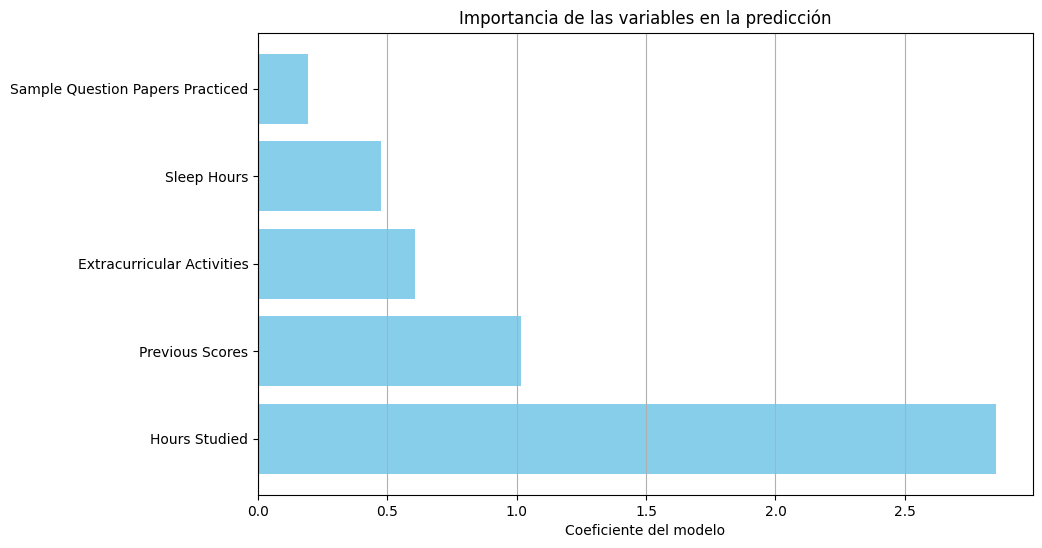

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Obtener coeficientes del modelo y nombres de las variables
coef = model.coef_
nombres = X.columns
# Crear gráfico de barras con la importancia
plt.figure(figsize=(10,6))
plt.barh(nombres, coef, color='skyblue')
plt.xlabel('Coeficiente del modelo')
plt.title('Importancia de las variables en la predicción')
plt.grid(axis='x')
plt.show()

Ejemplo de predicción

In [ ]:
import numpy as np
# Crear un array con los datos del nuevo estudiante (en el mismo orden que las columnas de X)
nuevo_estudiante = np.array([[6, 85, 1, 7, 3]])
# Hacer la predicción
prediccion = model.predict(nuevo_estudiante)
print(f"Predicción de Performance Index para el nuevo estudiante: {prediccion[0]:.2f}")

Predicción de Performance Index para el nuevo estudiante: 74.16


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
